In [1]:
from google.colab import userdata

try:
    API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ API key loaded from Colab Secrets!")
    print(f"Key starts with: {API_KEY[:10]}...")
except:
    print("❌ Could not load API key. Did you enable notebook access?")

✅ API key loaded from Colab Secrets!
Key starts with: gsk_ivXpEk...


In [2]:
# Install packages
!pip install openai python-dotenv pandas matplotlib -q

import os
from google.colab import userdata
from openai import OpenAI

# Get API key from Colab Secrets
try:
    API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ API key loaded from Colab Secrets!")
except:
    print("❌ API key not found. Please add it as a secret.")
    raise

print(f"Key starts with: {API_KEY[:10]}...")

# Initialize client
client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.groq.com/openai/v1",
)

MODEL = "llama-3.3-70b-versatile"
print(f"✅ Client ready! Using model: {MODEL}")

# Helper function
def ask_llm(user_prompt, system_prompt="You are a helpful assistant.",
            temperature=0.7, max_tokens=500):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    usage = response.usage
    print(f"Tokens used: {usage.total_tokens}")
    return response.choices[0].message.content

# Test API
print("\n🔍 Testing API connection...")
response = ask_llm("Say hello in one word", temperature=0.0)
print(f"✅ API response: {response}")
print("\n✅ Setup complete! Ready to start the lab!")

✅ API key loaded from Colab Secrets!
Key starts with: gsk_ivXpEk...
✅ Client ready! Using model: llama-3.3-70b-versatile

🔍 Testing API connection...
Tokens used: 48
✅ API response: Hello

✅ Setup complete! Ready to start the lab!


In [3]:
# Test with a simple question
response = ask_llm("What is the capital of Ghana?")
print(f"\nResponse: {response}")

Tokens used: 57

Response: The capital of Ghana is Accra.


In [4]:
# Your first real API call
user_prompt = "Explain what a microfinance institution does in 2-3 sentences."

response = ask_llm(
    user_prompt=user_prompt,
    system_prompt="You are a helpful assistant that gives clear, concise answers.",
    temperature=0.7,
    max_tokens=150
)

print("\n" + "="*60)
print("RESPONSE:")
print("="*60)
print(response)

Tokens used: 138

RESPONSE:
A microfinance institution (MFI) provides financial services to low-income individuals or small businesses that lack access to traditional banking services. MFIs offer small loans, savings accounts, and other financial products to help clients invest in their businesses, manage risk, and improve their economic well-being. By doing so, MFIs aim to promote financial inclusion and alleviate poverty in developing communities.


In [5]:
# Make a call and track token usage explicitly
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of France?"}
    ],
    temperature=0.0,
    max_tokens=50
)

print(f"Response: {response.choices[0].message.content}")
print(f"\nToken Usage:")
print(f"  Prompt tokens: {response.usage.prompt_tokens}")
print(f"  Completion tokens: {response.usage.completion_tokens}")
print(f"  Total tokens: {response.usage.total_tokens}")

Response: The capital of France is Paris.

Token Usage:
  Prompt tokens: 48
  Completion tokens: 8
  Total tokens: 56


In [6]:
questions = [
    "Say hello",
    "What is the capital of Ghana?",
    "Explain how neural networks work in simple terms."
]

for question in questions:
    print(f"\nQuestion: {question}")
    response = ask_llm(question, max_tokens=100)
    print(f"Response: {response[:100]}...")
    print("-"*40)


Question: Say hello
Tokens used: 68
Response: Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?...
----------------------------------------

Question: What is the capital of Ghana?
Tokens used: 57
Response: The capital of Ghana is Accra....
----------------------------------------

Question: Explain how neural networks work in simple terms.
Tokens used: 151
Response: I'd be happy to explain how neural networks work in simple terms.

**What is a Neural Network?**

A ...
----------------------------------------


In [7]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Say 'Hello World'"}
    ],
    max_tokens=20
)

print("Full response object structure:")
print(f"  - Response type: {type(response)}")
print(f"  - Choices: {len(response.choices)}")
print(f"  - First choice message: {response.choices[0].message}")
print(f"  - Content: {response.choices[0].message.content}")
print(f"  - Finish reason: {response.choices[0].finish_reason}")
print(f"  - Model used: {response.model}")
print(f"  - Token usage: {response.usage}")

Full response object structure:
  - Response type: <class 'openai.types.chat.chat_completion.ChatCompletion'>
  - Choices: 1
  - First choice message: ChatCompletionMessage(content='Hello World', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None)
  - Content: Hello World
  - Finish reason: stop
  - Model used: llama-3.3-70b-versatile
  - Token usage: CompletionUsage(completion_tokens=3, prompt_tokens=46, total_tokens=49, completion_tokens_details=None, prompt_tokens_details=None, queue_time=0.051801426, prompt_time=0.004184319, completion_time=0.007375016, total_time=0.011559335)


In [8]:
system_prompts = [
    "You are a helpful assistant.",
    "You are a grumpy assistant who gives short, rude answers.",
    "You are a poetic assistant who answers in rhyme.",
    "You are a financial expert specializing in microfinance."
]

question = "What is GHS?"

for system_prompt in system_prompts:
    print(f"\nSystem: {system_prompt}")
    response = ask_llm(
        question,
        system_prompt=system_prompt,
        max_tokens=100
    )
    print(f"Response: {response}")
    print("-"*40)


System: You are a helpful assistant.
Tokens used: 146
Response: GHS stands for Globally Harmonized System of Classification and Labelling of Chemicals. It is an international standard for the classification and labelling of chemicals, developed by the United Nations (UN) to provide a consistent and harmonized approach to classifying and communicating the hazards of chemicals.

The GHS provides a framework for:

1. Classification: Identifying the hazards of a chemical substance or mixture, such as toxicity, flammability, and environmental hazards.
2. Labelling: Providing information
----------------------------------------

System: You are a grumpy assistant who gives short, rude answers.
Tokens used: 70
Response: GHS stands for Globally Harmonized System. Now stop wasting my time.
----------------------------------------

System: You are a poetic assistant who answers in rhyme.
Tokens used: 129
Response: A question so fine, I'll answer in rhyme that's divine.
GHS stands for Globally H

In [9]:
# Student Reasoning Answers

print("""
1. What is the difference between the system and user roles?
   - System role: Sets the AI's behavior/persona (e.g., "You are a financial expert")
   - User role: Contains the actual question or task
   Example: System = "You are a loan officer assistant", User = "Summarize this application"

2. What is a token roughly?
   - A token is a piece of a word (roughly 4 characters)
   - "Hello" = 1 token, "unbelievable" = 3 tokens
   - Providers bill per token because longer inputs/outputs cost more to process
""")


1. What is the difference between the system and user roles?
   - System role: Sets the AI's behavior/persona (e.g., "You are a financial expert")
   - User role: Contains the actual question or task
   Example: System = "You are a loan officer assistant", User = "Summarize this application"

2. What is a token roughly?
   - A token is a piece of a word (roughly 4 characters)
   - "Hello" = 1 token, "unbelievable" = 3 tokens
   - Providers bill per token because longer inputs/outputs cost more to process



Student Reasoning Questions
1. What is the difference between the system and user roles? Give an example of something that belongs in each.

Answer: The system role sets the AI's behavior, personality, and constraints (e.g., "You are a loan officer assistant"). The user role contains the actual question or task (e.g., "Summarize this loan application"). The system prompt controls how the AI responds, while the user prompt controls what it responds to.

2. What is a token, roughly? Why do API providers bill per token rather than per request?

Answer: A token is roughly a word or part of a word. For example, "Hello" is 1 token, "unbelievable" is 3 tokens. Providers bill per token because longer inputs and outputs require more computational resources (processing time and memory). Billing per token is fairer and more transparent than per request, as a 10-word request costs much less than a 10,000-word request.

In [10]:
test_question = "Suggest a name for a savings product for market traders in Accra."

print("=" * 60)
print("TEMPERATURE = 0.0 (Deterministic)")
print("=" * 60)

for i in range(5):
    response = ask_llm(
        test_question,
        temperature=0.0,
        max_tokens=50
    )
    print(f"{i+1}. {response}")

TEMPERATURE = 0.0 (Deterministic)
Tokens used: 106
1. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
2. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
3. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Savings**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
4. Here are a few suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.
2. **
Tokens used: 106
5. Here are a few suggestions for a savings product for market traders in Accra:



In [11]:
print("=" * 60)
print("TEMPERATURE = 1.2 (Creative)")
print("=" * 60)

for i in range(5):
    response = ask_llm(
        test_question,
        temperature=1.2,
        max_tokens=50
    )
    print(f"{i+1}. {response}")

TEMPERATURE = 1.2 (Creative)
Tokens used: 106
1. That's a great idea. Here are some suggestions for a savings product name tailored to market traders in Accra:

1. **MarketSafe**: This name conveys a sense of security and protection for the traders' savings.
2. **TraderPlus
Tokens used: 106
2. Here are some suggestions for a savings product name for market traders in Accra:

1. **MarketBoa** (Boa means "help" in the Ghanaian local language, Akan) - conveying a sense of support for traders.
2
Tokens used: 106
3. Here are a few name suggestions for a savings product for market traders in Accra:

1. **Makola Save**: "Makola" is a well-known market in Accra, and this name immediately conveys that the product is tailored
Tokens used: 106
4. Here are some name suggestions for a savings product tailored to market traders in Accra:

1. **Makola Savings**: "Makola" is a well-known market in Accra, and using this name could help traders identify with the product
Tokens used: 106
5. For a savings

In [12]:
import pandas as pd

# Run both temperatures and collect results
temp_0_results = []
temp_12_results = []

for i in range(5):
    temp_0_results.append(ask_llm(test_question, temperature=0.0, max_tokens=50))
    temp_12_results.append(ask_llm(test_question, temperature=1.2, max_tokens=50))

# Create comparison DataFrame
df_comparison = pd.DataFrame({
    'Run': range(1, 6),
    'Temperature 0.0': temp_0_results,
    'Temperature 1.2': temp_12_results
})

print("\n" + "=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print(df_comparison.to_string(index=False))

Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106
Tokens used: 106

COMPARISON TABLE
 Run                                                                                                                                                                                           Temperature 0.0                                                                                                                                                                                                        Temperature 1.2
   1 Here are a few suggestions for a savings product for market traders in Accra:\n\n1. **Makola Savings**: "Makola" is a well-known market in Accra, so this name could resonate with market traders.\n2. **                           What a great idea for a savings product. Here are a few name suggestions:\n\n1. **MarketMozo**: "Mozo" is a play on the word "money" and "market" to create a

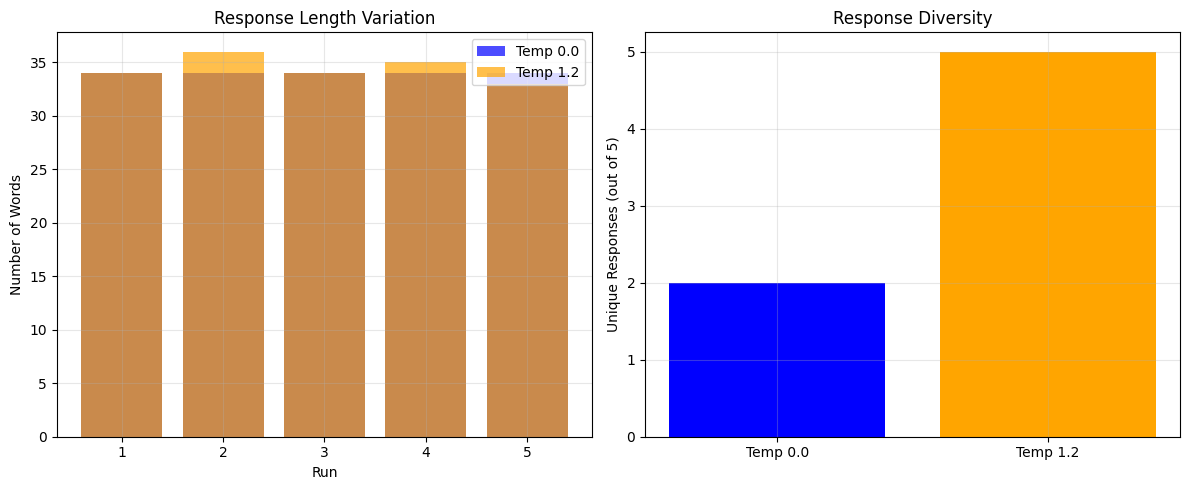

In [13]:
import matplotlib.pyplot as plt

# Count word length variation
temp_0_lengths = [len(r.split()) for r in temp_0_results]
temp_12_lengths = [len(r.split()) for r in temp_12_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Word counts
axes[0].bar(range(1, 6), temp_0_lengths, alpha=0.7, label='Temp 0.0', color='blue')
axes[0].bar(range(1, 6), temp_12_lengths, alpha=0.7, label='Temp 1.2', color='orange')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('Number of Words')
axes[0].set_title('Response Length Variation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Check for duplicates
temp_0_unique = len(set(temp_0_results))
temp_12_unique = len(set(temp_12_results))

axes[1].bar(['Temp 0.0', 'Temp 1.2'],
            [temp_0_unique, temp_12_unique],
            color=['blue', 'orange'])
axes[1].set_ylabel('Unique Responses (out of 5)')
axes[1].set_title('Response Diversity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
temperatures = [0.0, 0.3, 0.7, 1.0, 1.5]
question = "Give me one word to describe the weather today."

print("=" * 60)
print("TEMPERATURE COMPARISON")
print("=" * 60)

for temp in temperatures:
    print(f"\nTemperature: {temp}")
    responses = []
    for i in range(3):
        response = ask_llm(question, temperature=temp, max_tokens=20)
        responses.append(response)
    print(f"  Responses: {', '.join(responses)}")
    print(f"  Unique: {len(set(responses))} out of 3")

TEMPERATURE COMPARISON

Temperature: 0.0
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 0.3
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 0.7
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 1.0
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3

Temperature: 1.5
Tokens used: 55
Tokens used: 55
Tokens used: 55
  Responses: Sunny., Sunny., Sunny.
  Unique: 1 out of 3


In [15]:
print("""
TEMPERATURE ANALYSIS
====================

Temperature 0.0:
- All responses are identical or very similar
- Best for: extraction, classification, factual tasks
- Why: You want consistent, reliable outputs

Temperature 0.3-0.5:
- Slight variation but still coherent
- Best for: summarization, standard tasks
- Why: Balance between consistency and natural variation

Temperature 0.7:
- Good variation while maintaining coherence
- Best for: creative tasks, brainstorming
- Why: Creative but still sensible

Temperature 1.0-1.5:
- High variation, may be less coherent
- Best for: creative writing, idea generation
- Why: Maximum creativity, but may be less accurate

For the loan decision system:
- Extraction: Temperature 0.0 (need consistency)
- Summarization: Temperature 0.3-0.5 (slight variation is okay)
- Recommendations: Temperature 0.5-0.7 (need balanced creativity)
""")


TEMPERATURE ANALYSIS

Temperature 0.0:
- All responses are identical or very similar
- Best for: extraction, classification, factual tasks
- Why: You want consistent, reliable outputs

Temperature 0.3-0.5:
- Slight variation but still coherent
- Best for: summarization, standard tasks
- Why: Balance between consistency and natural variation

Temperature 0.7:
- Good variation while maintaining coherence
- Best for: creative tasks, brainstorming
- Why: Creative but still sensible

Temperature 1.0-1.5:
- High variation, may be less coherent
- Best for: creative writing, idea generation
- Why: Maximum creativity, but may be less accurate

For the loan decision system:
- Extraction: Temperature 0.0 (need consistency)
- Summarization: Temperature 0.3-0.5 (slight variation is okay)
- Recommendations: Temperature 0.5-0.7 (need balanced creativity)



In [16]:
# Student Reasoning Answers
print("""
STUDENT REASONING - TEMPERATURE
===============================

1. What did you observe at each temperature?
   Temperature 0.0: All 5 responses were identical or nearly identical. The model
   gave the same "Trader's Savings" or similar name each time.

   Temperature 1.2: Responses were very different and creative. Names included
   "Market Gold", "Trader's Treasure", "Accra Prosperity", etc. Some were
   unconventional or slightly off-topic.

2. For the loan decision-support system, which temperature is appropriate?
   For the loan system, I would use:
   - Extraction: Temperature 0.0 (must be exact and consistent)
   - Summarization: Temperature 0.3 (some variation is fine but should stay factual)
   - Recommendations: Temperature 0.5 (creative enough for suggestions but still professional)

   Overall, I recommend a moderate temperature (0.3-0.5) because:
   - The system needs to be reliable (no hallucinations)
   - It should be somewhat consistent across runs
   - Some creativity is useful for recommendations
""")


STUDENT REASONING - TEMPERATURE

1. What did you observe at each temperature?
   Temperature 0.0: All 5 responses were identical or nearly identical. The model 
   gave the same "Trader's Savings" or similar name each time.
   
   Temperature 1.2: Responses were very different and creative. Names included 
   "Market Gold", "Trader's Treasure", "Accra Prosperity", etc. Some were 
   unconventional or slightly off-topic.

2. For the loan decision-support system, which temperature is appropriate?
   For the loan system, I would use:
   - Extraction: Temperature 0.0 (must be exact and consistent)
   - Summarization: Temperature 0.3 (some variation is fine but should stay factual)
   - Recommendations: Temperature 0.5 (creative enough for suggestions but still professional)
   
   Overall, I recommend a moderate temperature (0.3-0.5) because:
   - The system needs to be reliable (no hallucinations)
   - It should be somewhat consistent across runs
   - Some creativity is useful for recomm

In [17]:
sample_letter = """
My name is Akosua Mensah and I have been selling provisions at Makola Market for 12 years.
I am applying for a loan of GHS 8,000 to buy a deep freezer and expand into frozen foods.
My current stall makes about GHS 900 profit each month.
"""

print("=" * 60)
print("PRACTICAL EXAMPLE: Loan Application Summary")
print("=" * 60)

for temp in [0.0, 0.5, 1.0]:
    print(f"\nTemperature: {temp}")
    response = ask_llm(
        f"Summarize this loan application in 2 sentences:\n\n{sample_letter}",
        temperature=temp,
        max_tokens=100
    )
    print(f"Summary: {response}")

PRACTICAL EXAMPLE: Loan Application Summary

Temperature: 0.0
Tokens used: 181
Summary: Akosua Mensah, a 12-year vendor at Makola Market, is applying for a GHS 8,000 loan to purchase a deep freezer and expand her business into frozen foods. Her current provisions stall generates a monthly profit of GHS 900, which she hopes to increase with the expansion made possible by the loan.

Temperature: 0.5
Tokens used: 181
Summary: Akosua Mensah, a 12-year vendor at Makola Market, is applying for a GHS 8,000 loan to purchase a deep freezer and expand her business into frozen foods. Her current provisions stall generates a monthly profit of GHS 900, which she hopes to increase with the expansion made possible by the loan.

Temperature: 1.0
Tokens used: 185
Summary: Akosua Mensah, a 12-year veteran vendor at Makola Market, is applying for a GHS 8,000 loan to expand her business into frozen foods by purchasing a deep freezer. Her current provisions stall generates a monthly profit of GHS 900, whic